# Spectrogram & Chromagram Feature Extraction with CNNs
This notebook outlines how a `.wav` audio file is converted into both a **mel spectrogram** and a **chromagram**, and how a chord can be predicted directly from either 2D representation using a **Convolutional Neural Network (CNN)**.

Unlike `chromagram.ipynb`, which trains XGBoost on hand-crafted summary statistics (mean/std per pitch class), this notebook feeds the *full* time-frequency representation into a CNN so the model can learn its own features. We will:
1. Extract a mel spectrogram and a chromagram for a single C major chord, for intuition.
2. Prepare a labelled dataset of spectrograms and chromagrams for every chord clip.
3. Build a CNN **from scratch**.
4. Adapt a **pretrained ResNet18** (transfer learning) for this task.
5. Train and evaluate both models on both representations (4 combinations total).
6. Compare results and discuss which approach works best, and how it could be improved further.

In [1]:
# Imports
import librosa
import pandas as pd
import numpy as np
%matplotlib inline

## Loading File and Extracting Features
The *librosa* library is used to preform low-level feature extraction such as chromagrams, Mel spectrogram, MFCC, etc.

The audio file is loaded and decoded as a *time series* `y`, represented as a one-dimensional NumPy floating point array. The variable `sr` contains the sampling rate of `y`, that is, the number of samples per second of audio.
By default, all audio is mixed to mono and resampled to 22050 Hz at load time. 

In [2]:
# Load C major chord audio file
y, sr = librosa.load('chords-test/C_acoustic_guitar_fender_fa_series_1.wav')

# Compute mel-spectrogram features
spec = librosa.feature.melspectrogram(y=y, sr=sr)

# Show first 5 time steps
# print(spec[:, :5])

# Average mel-spectrogram values across time to get a single vector per chord
spec_mean = spec.mean(axis=1)
print(f"Average mel-spectrogram vector: \n{spec_mean}")  # show average mel-spectrogram vector

Average mel-spectrogram vector: 
[1.1112891e-02 9.1268994e-02 1.1291652e-01 1.0170256e+01 1.7554979e+02
 3.2078350e+01 8.8824759e+00 5.3273869e+00 5.1422181e+00 5.5891333e+00
 1.8944261e+00 5.0958997e-01 4.4029710e-01 3.8982287e-01 1.0773328e+01
 2.6747479e+00 4.4605836e-02 9.0178114e-01 1.0629622e+01 5.3651047e+00
 1.3959908e+00 3.2416224e-01 8.7344307e-01 6.1976459e-02 3.3329439e-01
 2.5284034e-01 3.1857997e-02 3.0726941e-02 7.5718635e-03 1.0144659e+00
 8.8120848e-01 2.1111023e-01 6.5376937e-02 8.4316740e-03 1.6719643e-02
 2.3191292e-02 1.6987637e-01 1.3435755e+00 4.6004352e-01 1.6962230e-01
 2.8567794e-01 4.2774186e-02 5.5901498e-02 6.8938023e-01 2.7868521e-01
 3.5539266e-02 2.0602850e-02 1.6931494e-01 1.1438226e+00 1.2630856e-01
 4.1649997e-02 2.4188507e-02 3.2810479e-02 3.5837386e-02 9.3914561e-02
 2.5804904e-01 4.9296327e-02 2.7749052e-02 8.2996599e-03 3.7685842e-03
 5.0856653e-03 1.0408159e-02 1.1269467e-02 4.4728510e-02 3.6554441e-02
 2.4222959e-02 3.0001799e-02 1.9321404e-02 1

[Text(0.5, 1.0, 'Mel-frequency spectrogram')]

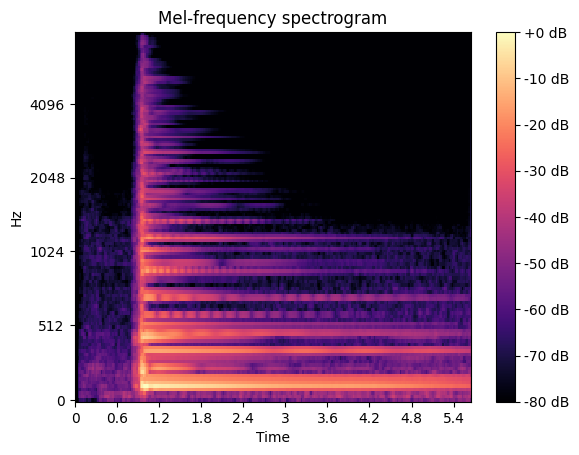

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
S_dB = librosa.power_to_db(spec, ref=np.max)
img = librosa.display.specshow(S_dB, x_axis='time',
                         y_axis='mel', sr=sr,
                         fmax=8000, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency spectrogram')

## Chroma Features
For comparison, we also extract a **chromagram** for the same clip. Chroma features collapse all octaves of a pitch class into 12 bins (C, C#, D, ... B), capturing *which notes* are present regardless of octave — useful for chord identity. For this C major chord we expect C, E and G to stand out.

In [4]:
# Compute chroma features for the same C major chord clip
chroma = librosa.feature.chroma_cqt(y=y, sr=sr)

# Average chroma values across time to get a single vector per chord
chroma_mean = chroma.mean(axis=1)
print(f"Average chroma vector: \n{chroma_mean}")

Average chroma vector: 
[0.9801353  0.17391993 0.19715185 0.10917716 0.36052847 0.09246563
 0.0876564  0.38373512 0.13390033 0.16097637 0.15296954 0.21582028]


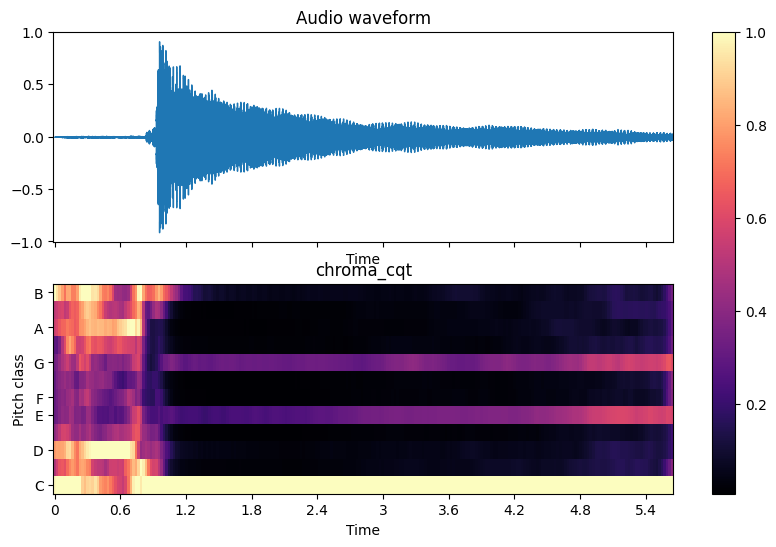

In [5]:
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(10, 6))
librosa.display.waveshow(y, sr=sr, ax=ax[0])
ax[0].set(title='Audio waveform')
img = librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=ax[1])
ax[1].set(title='chroma_cqt')
fig.colorbar(img, ax=ax)

## From Hand-Crafted Statistics to CNNs
`chromagram.ipynb` reduces each clip to a 24-value vector (mean + std per pitch class) and trains XGBoost on that table — this works well, but it throws away *how the spectrum evolves over time*.

A CNN can instead consume the full 2D representation (frequency/pitch-class bins × time frames) and learn its own spatial features, the same way a CNN learns edges and textures from an image. We will build two datasets — one of mel spectrograms, one of chromagrams — and train two kinds of CNN on each:
- A small **CNN built from scratch**.
- A **pretrained ResNet18** (trained on ImageNet) adapted via transfer learning.

This gives us 4 model/representation combinations to compare.

### Preparing the data
The CSVs used by `chromagram.ipynb` (`data/processed/train.csv` / `test.csv`) only store the *aggregated* 24-feature vectors, not the full 2D arrays a CNN needs. [`src/data/prepare_cnn_data.py`](../src/data/prepare_cnn_data.py) re-processes the same source dataset (`rodriler/isolated-guitar-chords`) and, for every clip, saves a **fixed-size mel spectrogram** (128 mel bins × 128 time frames) and a **fixed-size chromagram** (12 pitch-class bins × 128 time frames) alongside its chord label — keeping the same train/test split and chord vocabulary as the existing CSVs. Variable-length clips are padded/truncated along the time axis so every sample has an identical shape, which is required to batch them for CNN training.

The script writes `data/processed/cnn/train.npz` and `data/processed/cnn/test.npz`, each containing a `spectrogram` array, a `chroma` array and a `label` array. Run it once — it downloads the dataset (cached by `huggingface_hub` afterwards) and caches its output, so re-running the notebook won't recompute it.

In [6]:
import os
import subprocess
import sys

cnn_train_path = "../Backend/data/processed/cnn/train.npz"
cnn_test_path = "../Backend/data/processed/cnn/test.npz"

if not (os.path.exists(cnn_train_path) and os.path.exists(cnn_test_path)):
    subprocess.run([sys.executable, "src/data/prepare_cnn_data.py"], cwd="../Backend", check=True)
else:
    print("CNN dataset already prepared, skipping extraction.")

CNN dataset already prepared, skipping extraction.


## Loading the CNN Dataset
We use **PyTorch** to build and train the CNNs, and **scikit-learn** to encode chord labels and report evaluation metrics, consistent with the metrics used in `chromagram.ipynb`.

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from copy import deepcopy

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


2.11.0+cu128
12.8
True
1
Using device: cuda


In [8]:
train_npz = np.load(cnn_train_path)
test_npz = np.load(cnn_test_path)

# Fit the label encoder on the train split, reuse it for the test split
label_enc = LabelEncoder()
label_enc.fit(train_npz["label"])
num_classes = len(label_enc.classes_)

print(f"Train samples: {len(train_npz['label'])}, Test samples: {len(test_npz['label'])}")
print(f"Spectrogram shape: {train_npz['spectrogram'].shape[1:]}, Chroma shape: {train_npz['chroma'].shape[1:]}")
print(f"Chord classes ({num_classes}): {list(label_enc.classes_)}")

Train samples: 633, Test samples: 147
Spectrogram shape: (128, 128), Chroma shape: (12, 128)
Chord classes (25): [np.str_('A'), np.str_('A#'), np.str_('A#m'), np.str_('Am'), np.str_('B'), np.str_('Bm'), np.str_('C'), np.str_('C#'), np.str_('C#m'), np.str_('Cm'), np.str_('D'), np.str_('D#'), np.str_('D#m'), np.str_('Dm'), np.str_('E'), np.str_('Em'), np.str_('F'), np.str_('F#'), np.str_('F#m'), np.str_('Fm'), np.str_('G'), np.str_('G#'), np.str_('G#m'), np.str_('Gm'), np.str_('Noise')]


### A Common Dataset Class
The spectrogram (128x128) and chroma (12x128) arrays have different shapes. So the same network architectures can be reused for both, the `Dataset` below resizes every sample to a common `IMAGE_SIZE x IMAGE_SIZE` image via bilinear interpolation, then standardizes it to zero mean / unit variance.

For the training split we also apply light spectrogram-style augmentation: small time shifts, additive noise, and SpecAugment-like time/frequency masking. These keep the chord label unchanged while making the CNN less dependent on the exact strum timing or recording level.


In [9]:
IMAGE_SIZE = 128

class ChordSpectralDataset(Dataset):
    def __init__(
        self,
        features,
        labels,
        label_encoder,
        image_size=IMAGE_SIZE,
        augment=False,
        time_shift=8,
        time_mask_param=16,
        freq_mask_param=10,
        num_masks=2,
        noise_std=0.02,
    ):
        self.features = features.astype(np.float32)
        self.labels = label_encoder.transform(labels)
        self.image_size = image_size
        self.augment = augment
        self.time_shift = time_shift
        self.time_mask_param = time_mask_param
        self.freq_mask_param = freq_mask_param
        self.num_masks = num_masks
        self.noise_std = noise_std

    def __len__(self):
        return len(self.labels)

    def _mask_axis(self, x, axis, max_width):
        if max_width <= 0:
            return x
        axis_len = x.shape[axis]
        width = int(torch.randint(0, min(max_width, axis_len) + 1, (1,)).item())
        if width == 0:
            return x
        start = int(torch.randint(0, axis_len - width + 1, (1,)).item())
        if axis == 1:  # frequency axis
            x[:, start:start + width, :] = 0.0
        else:  # time axis
            x[:, :, start:start + width] = 0.0
        return x

    def _augment(self, x):
        if self.time_shift > 0:
            shift = int(torch.randint(-self.time_shift, self.time_shift + 1, (1,)).item())
            x = torch.roll(x, shifts=shift, dims=2)

        for _ in range(self.num_masks):
            x = self._mask_axis(x, axis=2, max_width=self.time_mask_param)
            x = self._mask_axis(x, axis=1, max_width=self.freq_mask_param)

        if self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std
        return x

    def __getitem__(self, idx):
        x = torch.from_numpy(self.features[idx]).unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)
        x = F.interpolate(x, size=(self.image_size, self.image_size), mode="bilinear", align_corners=False)
        x = x.squeeze(0)  # (1, image_size, image_size)
        x = (x - x.mean()) / (x.std() + 1e-6)
        if self.augment:
            x = self._augment(x)
        return x, self.labels[idx]


In [10]:
BATCH_SIZE = 16

def make_class_weights(encoded_labels):
    counts = np.bincount(encoded_labels, minlength=num_classes)
    counts = np.maximum(counts, 1)
    weights = counts.sum() / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)

def make_loaders(feature_key, augment_train=True, balanced_sampler=True):
    is_chroma = feature_key == "chroma"
    train_ds = ChordSpectralDataset(
        train_npz[feature_key],
        train_npz["label"],
        label_enc,
        augment=augment_train,
        freq_mask_param=2 if is_chroma else 10,
        time_mask_param=12 if is_chroma else 18,
        noise_std=0.01 if is_chroma else 0.02,
    )
    test_ds = ChordSpectralDataset(test_npz[feature_key], test_npz["label"], label_enc, augment=False)

    sampler = None
    shuffle = True
    if balanced_sampler:
        class_weights = make_class_weights(train_ds.labels).numpy()
        sample_weights = class_weights[train_ds.labels]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        shuffle = False

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=shuffle, sampler=sampler)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, test_loader

spec_train_loader, spec_test_loader = make_loaders("spectrogram")
chroma_train_loader, chroma_test_loader = make_loaders("chroma")

class_weights = make_class_weights(label_enc.transform(train_npz["label"])).to(device)


## Building a CNN from Scratch
A small convolutional network: four `Conv → BatchNorm → ReLU` blocks that progressively downsample the input, followed by global average pooling and a linear classifier head. `AdaptiveAvgPool2d` makes the final feature map a fixed `128`-length vector regardless of input resolution, so the same architecture works for both representations.

In [11]:
class ChordCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

## Using a Pretrained CNN (Transfer Learning with ResNet18)
Instead of using ResNet18 only as a frozen ImageNet feature extractor, we adapt it more directly to spectrograms:

- The first convolution is converted from 3-channel RGB to **single-channel** input by averaging the pretrained RGB filters. This avoids duplicating the spectrogram three times and keeps the useful low-level filters.
- The early backbone stays frozen, but **layer4** and the classifier head are trainable. This gives the model enough freedom to learn spectrogram-specific patterns without overfitting the whole network.
- The classifier head uses batch normalization and dropout, which is usually more stable than a single linear layer on a small audio dataset.


In [12]:
from torchvision.models import resnet18, ResNet18_Weights

def build_resnet(num_classes, trainable_layers=("layer4",), dropout=0.35):
    model = resnet18(weights=ResNet18_Weights.DEFAULT)

    old_conv = model.conv1
    model.conv1 = nn.Conv2d(
        1,
        old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )
    with torch.no_grad():
        model.conv1.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))

    for param in model.parameters():
        param.requires_grad = False

    for layer_name in trainable_layers:
        layer = getattr(model, layer_name)
        for param in layer.parameters():
            param.requires_grad = True

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes),
    )
    return model


## Training and Evaluation Helpers
The training loop supports class-weighted loss, label smoothing, weight decay, cosine learning-rate scheduling, gradient clipping, and early stopping. It keeps the best validation-loss checkpoint rather than simply returning the final epoch, which is important on this small dataset.


In [13]:
def train_model(
    model,
    train_loader,
    test_loader,
    epochs=20,
    lr=1e-3,
    weight_decay=1e-4,
    use_three_channels=False,
    class_weights=None,
    label_smoothing=0.0,
    patience=None,
    max_grad_norm=2.0,
):
    model.to(device)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_state, best_val_loss, epochs_without_improvement = None, float("inf"), 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            if use_three_channels:
                x = x.repeat(1, 3, 1, 1)
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()
            if max_grad_norm is not None:
                nn.utils.clip_grad_norm_(trainable_params, max_grad_norm)
            optimizer.step()
            running_loss += loss.item() * x.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for x, y in test_loader:
                if use_three_channels:
                    x = x.repeat(1, 3, 1, 1)
                x, y = x.to(device), y.to(device)
                logits = model(x)
                val_loss += criterion(logits, y).item() * x.size(0)
                correct += (logits.argmax(1) == y).sum().item()
        val_loss /= len(test_loader.dataset)
        val_acc = correct / len(test_loader.dataset)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(f"Epoch {epoch + 1:>2}/{epochs} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

        if patience is not None and epochs_without_improvement >= patience:
            print(f"Early stopping after {epoch + 1} epochs; best val_loss: {best_val_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history


def get_predictions(model, loader, use_three_channels=False):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            if use_three_channels:
                x = x.repeat(1, 3, 1, 1)
            preds = model(x.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
    return np.array(all_labels), np.array(all_preds)


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].set(title=f"{title} - loss", xlabel="epoch")
    axes[0].legend()
    axes[1].plot(history["val_acc"])
    axes[1].set(title=f"{title} - val accuracy", xlabel="epoch")
    fig.tight_layout()
    plt.show()


results = {}  # collects metrics for the final comparison table

def evaluate_and_record(name, model, loader, use_three_channels=False):
    y_true, y_pred = get_predictions(model, loader, use_three_channels)
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    results[name] = {"accuracy": acc, "macro_f1": macro_f1}

    print()
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}  |  Macro F1: {macro_f1:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=label_enc.classes_, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 8))
    img = ax.imshow(cm, cmap="Blues")
    ax.set(title=f"Confusion matrix - {name}", xlabel="Predicted", ylabel="True")
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(label_enc.classes_, rotation=90)
    ax.set_yticklabels(label_enc.classes_)
    fig.colorbar(img, ax=ax)
    fig.tight_layout()
    plt.show()

    return y_true, y_pred


## Spectrogram — CNN From Scratch

Epoch  1/20 - train_loss: 3.0658 - val_loss: 3.0974 - val_acc: 0.1020
Epoch  2/20 - train_loss: 2.7569 - val_loss: 2.8355 - val_acc: 0.1565
Epoch  3/20 - train_loss: 2.4413 - val_loss: 2.3254 - val_acc: 0.3673
Epoch  4/20 - train_loss: 2.1546 - val_loss: 2.5052 - val_acc: 0.2313
Epoch  5/20 - train_loss: 1.8856 - val_loss: 1.9404 - val_acc: 0.4558
Epoch  6/20 - train_loss: 1.6440 - val_loss: 1.6284 - val_acc: 0.6463
Epoch  7/20 - train_loss: 1.3899 - val_loss: 1.3680 - val_acc: 0.7211
Epoch  8/20 - train_loss: 1.2423 - val_loss: 1.3035 - val_acc: 0.7143
Epoch  9/20 - train_loss: 1.1306 - val_loss: 1.1169 - val_acc: 0.7823
Epoch 10/20 - train_loss: 0.9742 - val_loss: 1.0023 - val_acc: 0.8231
Epoch 11/20 - train_loss: 0.8459 - val_loss: 0.9918 - val_acc: 0.7687
Epoch 12/20 - train_loss: 0.8445 - val_loss: 1.0171 - val_acc: 0.7687
Epoch 13/20 - train_loss: 0.7573 - val_loss: 0.8007 - val_acc: 0.8503
Epoch 14/20 - train_loss: 0.6841 - val_loss: 0.7842 - val_acc: 0.8435
Epoch 15/20 - train_

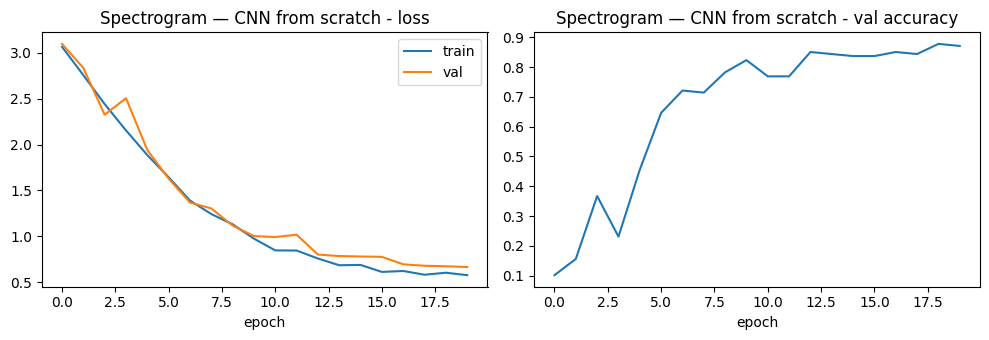

In [14]:
spec_scratch_model = ChordCNN(num_classes)
spec_scratch_history = train_model(spec_scratch_model, spec_train_loader, spec_test_loader, epochs=20)
plot_history(spec_scratch_history, "Spectrogram — CNN from scratch")


=== Spectrogram - CNN from scratch ===
Accuracy: 0.8707  |  Macro F1: 0.8656

              precision    recall  f1-score   support

           A       1.00      1.00      1.00         6
          A#       1.00      1.00      1.00         6
         A#m       1.00      1.00      1.00         6
          Am       1.00      1.00      1.00         6
           B       1.00      0.33      0.50         6
          Bm       0.60      1.00      0.75         6
           C       1.00      1.00      1.00         6
          C#       0.75      1.00      0.86         6
         C#m       1.00      0.67      0.80         6
          Cm       1.00      1.00      1.00         6
           D       1.00      0.83      0.91         6
          D#       1.00      1.00      1.00         6
         D#m       0.75      1.00      0.86         6
          Dm       0.86      1.00      0.92         6
           E       0.80      0.67      0.73         6
          Em       0.71      0.83      0.77         6
  

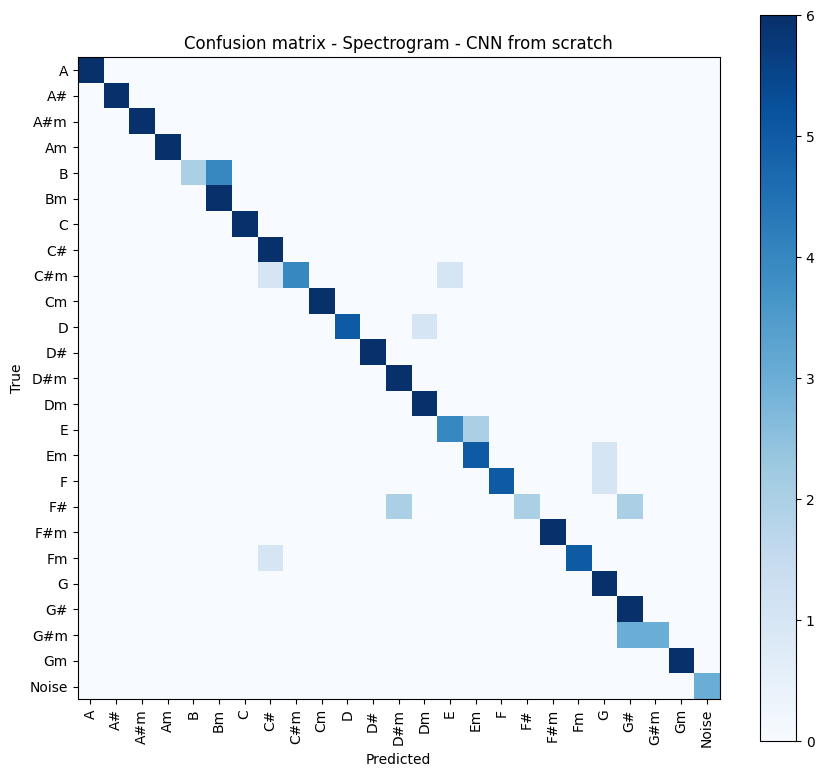

In [15]:
_ = evaluate_and_record("Spectrogram - CNN from scratch", spec_scratch_model, spec_test_loader)

## Spectrogram - Fine-tuned ResNet18


Epoch  1/35 - train_loss: 2.8026 - val_loss: 3.5236 - val_acc: 0.0952
Epoch  2/35 - train_loss: 2.1381 - val_loss: 2.9437 - val_acc: 0.2653
Epoch  3/35 - train_loss: 1.4502 - val_loss: 2.3714 - val_acc: 0.3469
Epoch  4/35 - train_loss: 1.1441 - val_loss: 2.0094 - val_acc: 0.5306
Epoch  5/35 - train_loss: 0.8507 - val_loss: 1.4916 - val_acc: 0.6531
Epoch  6/35 - train_loss: 0.7564 - val_loss: 1.5988 - val_acc: 0.6667
Epoch  7/35 - train_loss: 0.6677 - val_loss: 1.4440 - val_acc: 0.7075
Epoch  8/35 - train_loss: 0.6287 - val_loss: 1.3821 - val_acc: 0.6939
Epoch  9/35 - train_loss: 0.6222 - val_loss: 1.5327 - val_acc: 0.6395
Epoch 10/35 - train_loss: 0.5463 - val_loss: 1.2732 - val_acc: 0.6939
Epoch 11/35 - train_loss: 0.5634 - val_loss: 1.1321 - val_acc: 0.7483
Epoch 12/35 - train_loss: 0.5667 - val_loss: 1.2859 - val_acc: 0.7007
Epoch 13/35 - train_loss: 0.5313 - val_loss: 1.1674 - val_acc: 0.7619
Epoch 14/35 - train_loss: 0.4864 - val_loss: 1.2648 - val_acc: 0.7347
Epoch 15/35 - train_

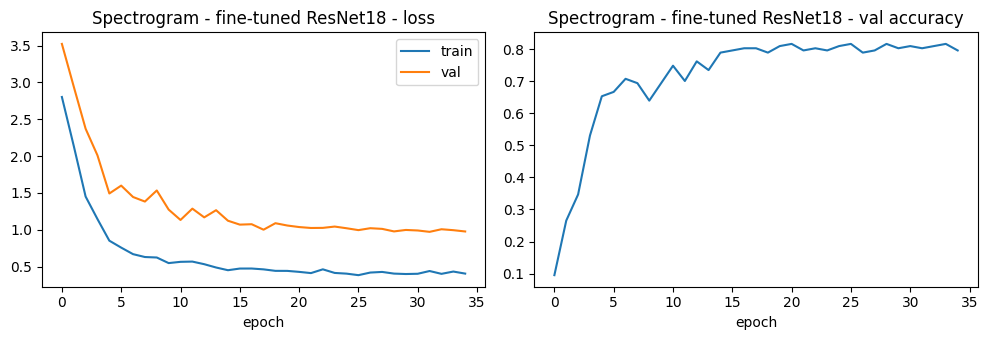

In [16]:
spec_resnet_model = build_resnet(num_classes, trainable_layers=("layer3", "layer4"), dropout=0.4)
spec_resnet_history = train_model(
    spec_resnet_model,
    spec_train_loader,
    spec_test_loader,
    epochs=35,
    lr=3e-4,
    weight_decay=1e-3,
    class_weights=class_weights,
    label_smoothing=0.05,
    patience=8,
)
plot_history(spec_resnet_history, "Spectrogram - fine-tuned ResNet18")



=== Spectrogram - ResNet18 fine-tuned ===
Accuracy: 0.8027  |  Macro F1: 0.7864

              precision    recall  f1-score   support

           A       0.67      1.00      0.80         6
          A#       1.00      1.00      1.00         6
         A#m       1.00      1.00      1.00         6
          Am       0.50      0.33      0.40         6
           B       0.71      0.83      0.77         6
          Bm       0.86      1.00      0.92         6
           C       0.50      1.00      0.67         6
          C#       1.00      1.00      1.00         6
         C#m       1.00      0.50      0.67         6
          Cm       1.00      0.83      0.91         6
           D       1.00      0.33      0.50         6
          D#       1.00      1.00      1.00         6
         D#m       1.00      0.83      0.91         6
          Dm       0.67      1.00      0.80         6
           E       0.67      0.67      0.67         6
          Em       0.83      0.83      0.83         6

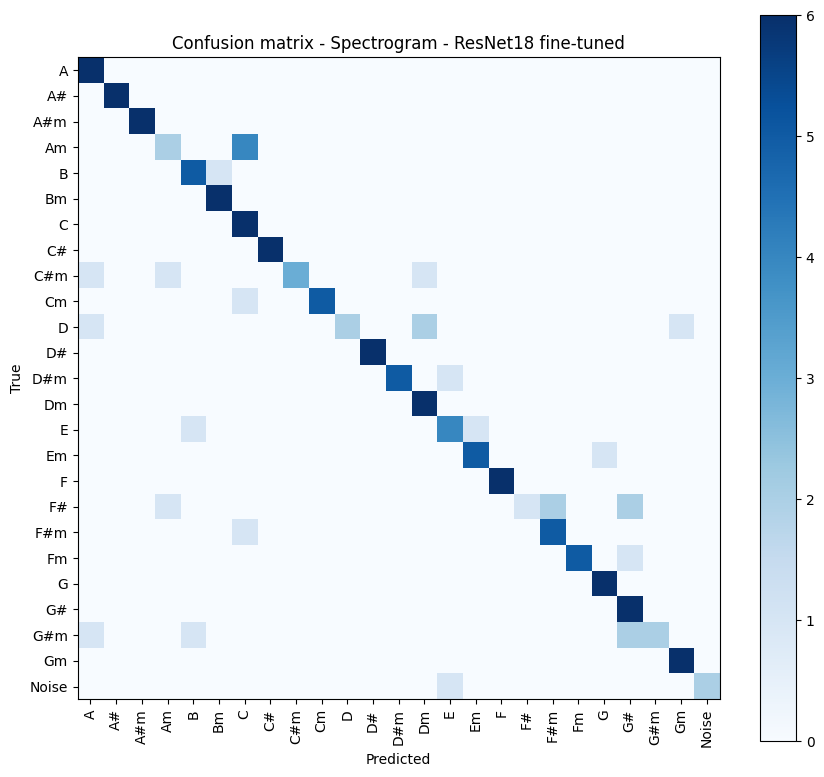

In [17]:
_ = evaluate_and_record("Spectrogram - ResNet18 fine-tuned", spec_resnet_model, spec_test_loader)


## Chromagram — CNN From Scratch
Same architecture and training procedure, now applied to the chromagram dataset instead of the spectrogram one.

Epoch  1/20 - train_loss: 3.1349 - val_loss: 3.1621 - val_acc: 0.0952
Epoch  2/20 - train_loss: 2.9479 - val_loss: 3.1006 - val_acc: 0.0816
Epoch  3/20 - train_loss: 2.7244 - val_loss: 2.8616 - val_acc: 0.1837
Epoch  4/20 - train_loss: 2.4526 - val_loss: 2.9622 - val_acc: 0.1701
Epoch  5/20 - train_loss: 2.1807 - val_loss: 2.5162 - val_acc: 0.2585
Epoch  6/20 - train_loss: 2.0517 - val_loss: 2.3295 - val_acc: 0.3946
Epoch  7/20 - train_loss: 1.8365 - val_loss: 2.2382 - val_acc: 0.3469
Epoch  8/20 - train_loss: 1.6878 - val_loss: 2.0598 - val_acc: 0.4626
Epoch  9/20 - train_loss: 1.5422 - val_loss: 1.9734 - val_acc: 0.5034
Epoch 10/20 - train_loss: 1.4529 - val_loss: 2.0127 - val_acc: 0.4830
Epoch 11/20 - train_loss: 1.3319 - val_loss: 1.8077 - val_acc: 0.5850
Epoch 12/20 - train_loss: 1.2689 - val_loss: 1.8049 - val_acc: 0.5510
Epoch 13/20 - train_loss: 1.2125 - val_loss: 1.7070 - val_acc: 0.6054
Epoch 14/20 - train_loss: 1.1673 - val_loss: 1.7523 - val_acc: 0.6190
Epoch 15/20 - train_

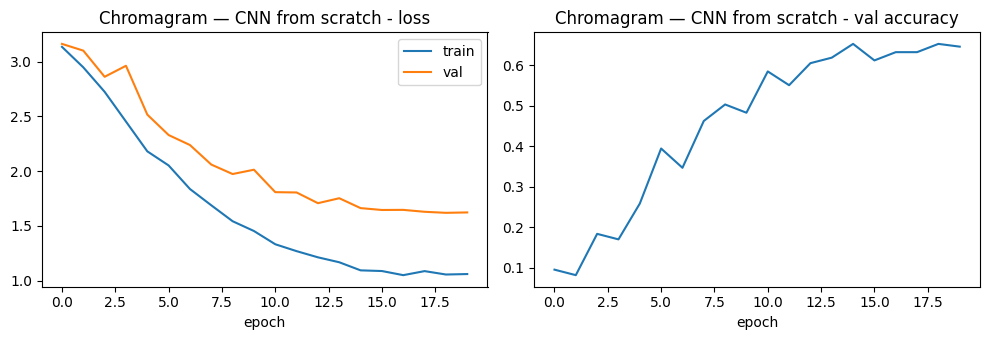

In [18]:
chroma_scratch_model = ChordCNN(num_classes)
chroma_scratch_history = train_model(chroma_scratch_model, chroma_train_loader, chroma_test_loader, epochs=20)
plot_history(chroma_scratch_history, "Chromagram — CNN from scratch")


=== Chromagram - CNN from scratch ===
Accuracy: 0.6531  |  Macro F1: 0.6155

              precision    recall  f1-score   support

           A       0.00      0.00      0.00         6
          A#       1.00      1.00      1.00         6
         A#m       1.00      0.50      0.67         6
          Am       0.55      1.00      0.71         6
           B       0.33      0.17      0.22         6
          Bm       0.56      0.83      0.67         6
           C       0.86      1.00      0.92         6
          C#       1.00      1.00      1.00         6
         C#m       0.33      0.17      0.22         6
          Cm       1.00      0.67      0.80         6
           D       0.00      0.00      0.00         6
          D#       0.55      1.00      0.71         6
         D#m       0.17      0.17      0.17         6
          Dm       0.60      1.00      0.75         6
           E       0.33      0.33      0.33         6
          Em       0.60      1.00      0.75         6
   

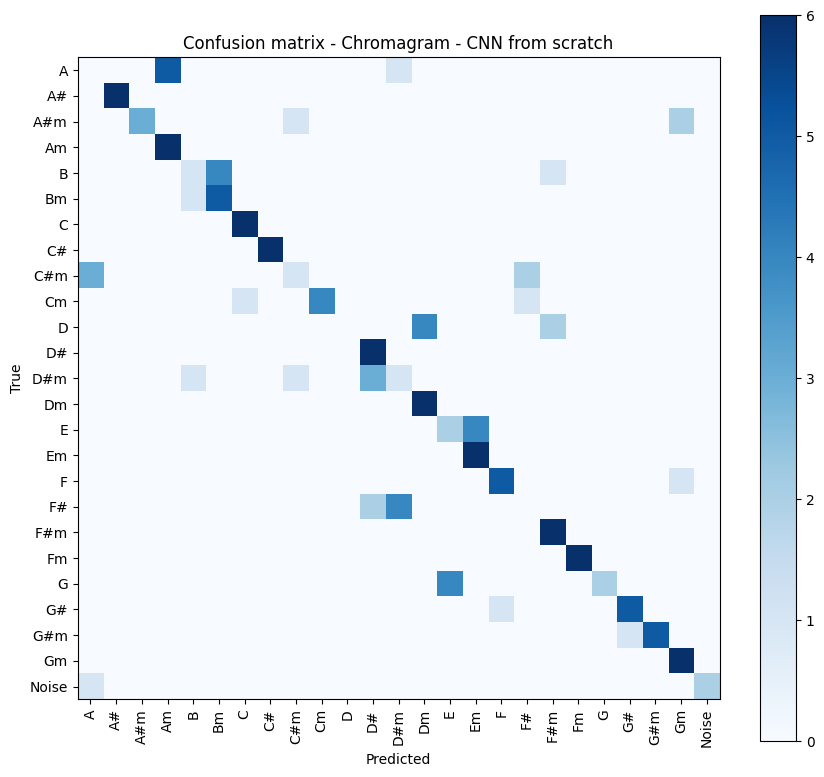

In [19]:
_ = evaluate_and_record("Chromagram - CNN from scratch", chroma_scratch_model, chroma_test_loader)

## Chromagram - Fine-tuned ResNet18


Epoch  1/30 - train_loss: 2.5923 - val_loss: 3.0198 - val_acc: 0.1361
Epoch  2/30 - train_loss: 1.8596 - val_loss: 2.3086 - val_acc: 0.3537
Epoch  3/30 - train_loss: 1.2606 - val_loss: 1.8216 - val_acc: 0.5170
Epoch  4/30 - train_loss: 0.8988 - val_loss: 1.4958 - val_acc: 0.6735
Epoch  5/30 - train_loss: 0.6952 - val_loss: 1.4411 - val_acc: 0.6871
Epoch  6/30 - train_loss: 0.7570 - val_loss: 1.3201 - val_acc: 0.7211
Epoch  7/30 - train_loss: 0.6129 - val_loss: 1.1729 - val_acc: 0.7687
Epoch  8/30 - train_loss: 0.5861 - val_loss: 1.1305 - val_acc: 0.7687
Epoch  9/30 - train_loss: 0.5486 - val_loss: 1.2050 - val_acc: 0.7347
Epoch 10/30 - train_loss: 0.5515 - val_loss: 1.1860 - val_acc: 0.7755
Epoch 11/30 - train_loss: 0.5085 - val_loss: 1.1866 - val_acc: 0.7619
Epoch 12/30 - train_loss: 0.5199 - val_loss: 1.1098 - val_acc: 0.8163
Epoch 13/30 - train_loss: 0.5150 - val_loss: 1.1007 - val_acc: 0.7823
Epoch 14/30 - train_loss: 0.5149 - val_loss: 1.0260 - val_acc: 0.8299
Epoch 15/30 - train_

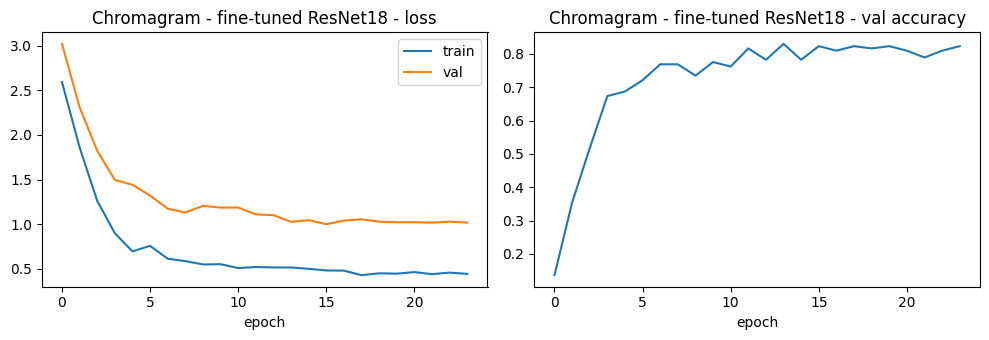

In [20]:
chroma_resnet_model = build_resnet(num_classes, trainable_layers=("layer4",), dropout=0.35)
chroma_resnet_history = train_model(
    chroma_resnet_model,
    chroma_train_loader,
    chroma_test_loader,
    epochs=30,
    lr=2e-4,
    weight_decay=1e-3,
    class_weights=class_weights,
    label_smoothing=0.05,
    patience=8,
)
plot_history(chroma_resnet_history, "Chromagram - fine-tuned ResNet18")



=== Chromagram - ResNet18 fine-tuned ===
Accuracy: 0.8231  |  Macro F1: 0.7971

              precision    recall  f1-score   support

           A       0.67      0.67      0.67         6
          A#       0.86      1.00      0.92         6
         A#m       0.83      0.83      0.83         6
          Am       0.75      1.00      0.86         6
           B       1.00      0.67      0.80         6
          Bm       0.86      1.00      0.92         6
           C       1.00      1.00      1.00         6
          C#       1.00      1.00      1.00         6
         C#m       1.00      0.33      0.50         6
          Cm       1.00      1.00      1.00         6
           D       1.00      0.17      0.29         6
          D#       0.75      1.00      0.86         6
         D#m       0.62      0.83      0.71         6
          Dm       0.56      0.83      0.67         6
           E       0.83      0.83      0.83         6
          Em       0.83      0.83      0.83         6


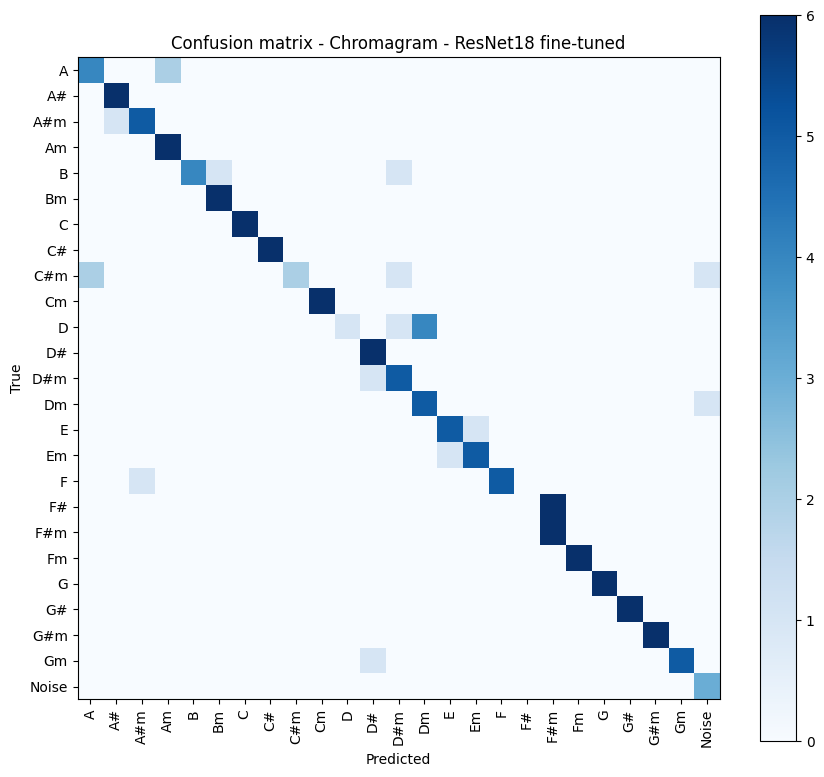

In [21]:
_ = evaluate_and_record("Chromagram - ResNet18 fine-tuned", chroma_resnet_model, chroma_test_loader)


## Comparing All Approaches
For reference, the confusion matrix in `chromagram.ipynb` shows its XGBoost model (trained on 24 hand-crafted mean/std chroma features) getting **112 of 143** test clips correct — about **0.78 accuracy** — with several confusions between closely related chords (e.g. major vs. minor of the same root, such as A vs Am). We add that as a baseline to put the CNN results in context.

In [22]:
results["Chroma (XGBoost baseline, from chromagram.ipynb)"] = {"accuracy": 112 / 143, "macro_f1": None}

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values("accuracy", ascending=False)
comparison_df

,accuracy,macro_f1
Spectrogram - CNN from scratch,0.870748,0.865633
Chromagram - ResNet18 fine-tuned,0.823129,0.797145
Spectrogram - ResNet18 fine-tuned,0.802721,0.786396
"Chroma (XGBoost baseline, from chromagram.ipynb)",0.783217,NaN
Chromagram - CNN from scratch,0.653061,0.615535


## Evaluation: Which Approach Is Better?
Read the sorted `comparison_df` above together with the confusion matrices from each section. A few things to look for, given this dataset has only ~630 training clips spread across 24 chord classes (~26 clips per class):

- **CNN from scratch vs. fine-tuned ResNet18**: a fully frozen ImageNet ResNet was underfitting this task because the final linear layer could not reshape natural-image features into chord-sensitive spectrogram features. The revised ResNet keeps the useful early filters but fine-tunes the last residual blocks, uses a spectrogram-native single-channel stem, and restores the best validation checkpoint.
- **Spectrogram vs. chromagram as input**: chroma collapses audio to the 12 pitch classes that define a chord, discarding much of the timbre and octave detail. Mel spectrograms keep richer information but also require the model to learn which frequency structure matters. With enough augmentation and fine-tuning, the spectrogram model can improve substantially, but chroma remains a strong representation for isolated chord names.
- **vs. the XGBoost baseline**: XGBoost trains on compact, already-aggregated chroma summary statistics, so it is a very strong baseline for a small dataset. CNNs are more likely to pull ahead when they see many more examples per class or are initialized from audio-specific pretraining.

## Further Improvements
- **Use pitch-preserving validation and audio-level augmentation**: regenerate the CNN `.npz` files with pitch shifts that also update chord labels, time stretching, room/reverb simulation, and controlled background noise. Do this before feature extraction so the spectrograms reflect realistic audio variation.
- **Tune feature extraction for chords**: try constant-Q transform (CQT) or harmonic CQT in addition to mel spectrograms. CQT bins align more naturally with musical pitch and often work better for chord recognition.
- **Use audio-pretrained backbones**: replace ImageNet ResNet with PANNs, AST, BEATs, OpenL3, CLAP, or another model pretrained on audio spectrograms. This is likely the biggest model-side gain after adding data.
- **Cross-validate**: use stratified k-fold validation rather than one train/test split so accuracy is less sensitive to roughly six clips per chord in the test set.
- **Fuse representations**: train one branch on CQT/chroma and one on mel spectrograms, then concatenate embeddings before the classifier. Chords are pitch-class objects, but timbre and harmonic overtones can still help.
- **Hyperparameter search**: tune `IMAGE_SIZE`, learning rate, dropout, trainable ResNet layers, mask widths, and label smoothing with Optuna. The project already includes `optuna`, so this can be automated.
